# Geometric Intersection and Linear‑Programming Packing with Touching

We extend the previous separation model to **encourage or enforce contact** between polygons.
The goal: move polygons minimally so that no two overlap, and **as many pairs as possible touch**.

This is formulated as a MILP with:
- Translation variables `(dx_i, dy_i)`
- Separating‑axis constraints for non‑overlap
- Binary variables `touch_{ij}` indicating contact
- Objective: maximize weighted sum of `touch_{ij}` minus a small penalty on movement.


## 1. Imports and Utilities

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from scipy.spatial import ConvexHull
import pulp
import itertools

## 2. Sweep‑Line Intersection Detection (Shamos‑Hoey)

In [54]:
class Event:
    def __init__(self, x, y, segment, is_left):
        self.x = x
        self.y = y
        self.segment = segment
        self.is_left = is_left
    def __lt__(self, other):
        return (self.x, self.y) < (other.x, other.y)

class Segment:
    def __init__(self, p1, p2):
        if p1[0] < p2[0] or (p1[0] == p2[0] and p1[1] < p2[1]):
            self.p1 = np.array(p1, dtype=float)
            self.p2 = np.array(p2, dtype=float)
        else:
            self.p1 = np.array(p2, dtype=float)
            self.p2 = np.array(p1, dtype=float)
    def y_at(self, x):
        if self.p2[0] == self.p1[0]:
            return self.p1[1]
        t = (x - self.p1[0]) / (self.p2[0] - self.p1[0])
        return self.p1[1] + t * (self.p2[1] - self.p1[1])

def on_segment(A, B, P):
    return (min(A[0], B[0]) <= P[0] <= max(A[0], B[0]) and
            min(A[1], B[1]) <= P[1] <= max(A[1], B[1]))

def segments_intersect(s1, s2):
    def ccw(A, B, C):
        return (B[0]-A[0])*(C[1]-A[1]) - (B[1]-A[1])*(C[0]-A[0])
    A, B = s1.p1, s1.p2
    C, D = s2.p1, s2.p2
    if (max(A[0], B[0]) < min(C[0], D[0]) or max(C[0], D[0]) < min(A[0], B[0]) or
        max(A[1], B[1]) < min(C[1], D[1]) or max(C[1], D[1]) < min(A[1], B[1])):
        return False
    o1 = ccw(A, B, C)
    o2 = ccw(A, B, D)
    o3 = ccw(C, D, A)
    o4 = ccw(C, D, B)
    if o1 * o2 < 0 and o3 * o4 < 0:
        return True
    if o1 == 0 and on_segment(A, B, C): return True
    if o2 == 0 and on_segment(A, B, D): return True
    if o3 == 0 and on_segment(C, D, A): return True
    if o4 == 0 and on_segment(C, D, B): return True
    return False

def any_intersection(segments):
    events = []
    for seg in segments:
        events.append(Event(seg.p1[0], seg.p1[1], seg, True))
        events.append(Event(seg.p2[0], seg.p2[1], seg, False))
    events.sort()
    active = []
    def y_order(s1, s2, x):
        y1 = s1.y_at(x)
        y2 = s2.y_at(x)
        if abs(y1 - y2) < 1e-9:
            if s1.p2[0] == s1.p1[0] and s2.p2[0] == s2.p1[0]:
                return 0
            if s1.p2[0] == s1.p1[0]:
                return -1
            if s2.p2[0] == s2.p1[0]:
                return 1
            slope1 = (s1.p2[1] - s1.p1[1]) / (s1.p2[0] - s1.p1[0])
            slope2 = (s2.p2[1] - s2.p1[1]) / (s2.p2[0] - s2.p1[0])
            return -1 if slope1 < slope2 else (1 if slope1 > slope2 else 0)
        return -1 if y1 < y2 else 1
    for ev in events:
        seg = ev.segment
        if ev.is_left:
            idx = 0
            while idx < len(active) and y_order(active[idx], seg, ev.x) <= 0:
                idx += 1
            active.insert(idx, seg)
            if idx > 0 and segments_intersect(active[idx-1], seg):
                return True
            if idx < len(active)-1 and segments_intersect(seg, active[idx+1]):
                return True
        else:
            idx = active.index(seg)
            if idx > 0 and idx < len(active)-1:
                if segments_intersect(active[idx-1], active[idx+1]):
                    return True
            del active[idx]
    return False

def polygons_intersect_shamos(poly1, poly2):
    edges = []
    for i in range(len(poly1)):
        edges.append(Segment(poly1[i], poly1[(i+1)%len(poly1)]))
    for i in range(len(poly2)):
        edges.append(Segment(poly2[i], poly2[(i+1)%len(poly2)]))
    return any_intersection(edges)

def find_intersecting_pairs_shamos(polygons):
    n = len(polygons)
    pairs = []
    for i in range(n):
        for j in range(i+1, n):
            if polygons_intersect_shamos(polygons[i], polygons[j]):
                pairs.append((i,j))
    return pairs

## 3. Random Convex Polygon Generation

In [55]:
def random_convex_polygon(num_vertices=5, center=(0,0), scale=1.0):
    angles = np.sort(np.random.uniform(0, 2*np.pi, num_vertices))
    radii = np.random.uniform(0.5*scale, scale, num_vertices)
    x = center[0] + radii * np.cos(angles)
    y = center[1] + radii * np.sin(angles)
    points = np.column_stack([x, y])
    hull = ConvexHull(points)
    return points[hull.vertices]

def plot_polygons(polygons, colors=None, title="", ax=None, show_indices=True):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0,1,len(polygons)))
    for i, poly in enumerate(polygons):
        patch = MPLPolygon(poly, closed=True, facecolor=colors[i], 
                           edgecolor='black', alpha=0.6, linewidth=2)
        ax.add_patch(patch)
        if show_indices:
            centroid = np.mean(poly, axis=0)
            ax.text(centroid[0], centroid[1], f'{i}', ha='center', va='center', fontweight='bold')
    ax.set_aspect('equal')
    ax.autoscale()
    ax.set_title(title)
    return ax

## 4. Generate and Visualize Initial Polygons

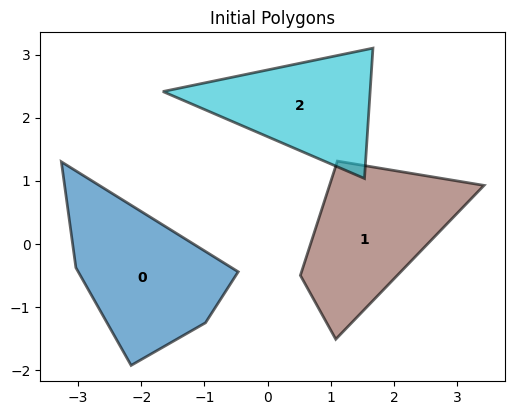

Intersecting pairs: [(0, 1), (0, 2), (1, 2)]


In [56]:
np.random.seed(32)
num_polygons = 3
centers = [(-2,0), (2,0), (0,2)]
polygons = []
for i in range(num_polygons):
    poly = random_convex_polygon(5, center=centers[i], scale=2.0)
    polygons.append(poly)

ax = plot_polygons(polygons, title="Initial Polygons")
plt.show()

pairs = find_intersecting_pairs_shamos(polygons)
print("Intersecting pairs:", pairs)

## 5. MILP for Minimal Movement with Touching Incentive

We formulate a MILP that:
- Moves each polygon by `(dx_i, dy_i)`.
- Ensures no two polygons overlap (using separating‑axis constraints).
- Introduces binary variables `touch_{ij}` that can be 1 only if polygons `i` and `j` are touching (distance = 0 along some axis).
- Maximizes the sum of `touch_{ij}` while minimizing a small penalty on total movement.

**Touching condition:**  
For a pair `(i,j)`, if they touch, there must exist at least one separating axis where the gap between their projections is **exactly zero** (within a small tolerance). We use an additional binary per axis to indicate contact, and enforce that `touch_{ij}` ≤ sum of axis‑contact indicators.

Because exact zero is numerically delicate, we allow a small tolerance `ε` and treat distances ≤ ε as contact.

In [57]:
def separating_axes(poly):
    axes = []
    n = len(poly)
    for i in range(n):
        p1 = poly[i]
        p2 = poly[(i+1)%n]
        edge = p2 - p1
        normal = np.array([-edge[1], edge[0]])
        norm = np.linalg.norm(normal)
        if norm > 1e-9:
            axes.append(normal / norm)
    return axes

def project_polygon(poly, axis):
    dots = np.dot(poly, axis)
    return np.min(dots), np.max(dots)

def build_touching_milp(polygons, max_move=20.0, touch_penalty_weight=10.0, epsilon=1e-4):
    n = len(polygons)
    prob = pulp.LpProblem("SeparatePolygons", pulp.LpMinimize)
    
    dx = [pulp.LpVariable(f"dx_{i}", -max_move, max_move) for i in range(n)]
    dy = [pulp.LpVariable(f"dy_{i}", -max_move, max_move) for i in range(n)]
    
    # Objective: L1 sum of moves
    abs_dx = [pulp.LpVariable(f"abs_dx_{i}", 0, max_move) for i in range(n)]
    abs_dy = [pulp.LpVariable(f"abs_dy_{i}", 0, max_move) for i in range(n)]
    for i in range(n):
        prob += dx[i] <= abs_dx[i]
        prob += -dx[i] <= abs_dx[i]
        prob += dy[i] <= abs_dy[i]
        prob += -dy[i] <= abs_dy[i]
    prob += pulp.lpSum(abs_dx[i] + abs_dy[i] for i in range(n))
    
    import itertools
    for i, j in itertools.combinations(range(n), 2):
        axes_i = separating_axes(polygons[i])
        axes_j = separating_axes(polygons[j])
        all_axes = axes_i + axes_j
        
        z = [pulp.LpVariable(f"z_{i}_{j}_{k}", cat=pulp.LpBinary) for k in range(len(all_axes))]
        prob += pulp.lpSum(z) >= 1
        
        M = 1000
        for k, axis in enumerate(all_axes):
            min_i, max_i = project_polygon(polygons[i], axis)
            min_j, max_j = project_polygon(polygons[j], axis)
            dot_i = axis[0]*dx[i] + axis[1]*dy[i]
            dot_j = axis[0]*dx[j] + axis[1]*dy[j]
            w = pulp.LpVariable(f"w_{i}_{j}_{k}", cat=pulp.LpBinary)
            prob += max_i + dot_i - (min_j + dot_j) <= M * (1 - z[k]) + M * (1 - w)
            prob += max_j + dot_j - (min_i + dot_i) <= M * (1 - z[k]) + M * w
    
    return prob, dx, dy, {}

# def build_touching_milp(polygons, max_move=5.0, touch_penalty_weight=10.0, epsilon=1e-4):
    """
    Build MILP to move polygons minimally while maximizing number of touching pairs.
    
    Parameters:
        polygons: list of convex polygons (Nx2 arrays)
        max_move: bound on dx, dy
        touch_penalty_weight: weight for number of touches (positive -> maximize touches)
        epsilon: tolerance for considering a gap as zero (touching)
    
    Returns:
        prob, dx_vars, dy_vars, touch_vars
    """
    n = len(polygons)
    prob = pulp.LpProblem("PackWithTouching", pulp.LpMaximize)
    
    # Translation variables
    dx = [pulp.LpVariable(f"dx_{i}", -max_move, max_move) for i in range(n)]
    dy = [pulp.LpVariable(f"dy_{i}", -max_move, max_move) for i in range(n)]
    
    # Absolute movement variables for penalty
    abs_dx = [pulp.LpVariable(f"abs_dx_{i}", 0, max_move) for i in range(n)]
    abs_dy = [pulp.LpVariable(f"abs_dy_{i}", 0, max_move) for i in range(n)]
    for i in range(n):
        prob += dx[i] <= abs_dx[i]
        prob += -dx[i] <= abs_dx[i]
        prob += dy[i] <= abs_dy[i]
        prob += -dy[i] <= abs_dy[i]
    
    # Binary variables for each pair indicating touch
    touch = {}
    for i, j in itertools.combinations(range(n), 2):
        touch[(i,j)] = pulp.LpVariable(f"touch_{i}_{j}", cat=pulp.LpBinary)
    
    # Objective: maximize touches - small penalty on movement
    total_move = pulp.lpSum(abs_dx[i] + abs_dy[i] for i in range(n))
    total_touch = pulp.lpSum(touch.values())
    # Scale movement penalty to be small compared to touch reward
    # If touch_penalty_weight is large, touches dominate
    prob += total_touch - (1.0 / touch_penalty_weight) * total_move
    
    M = 1000  # big-M
    
    # For each pair, add separation constraints and touch detection
    for i, j in itertools.combinations(range(n), 2):
        axes_i = separating_axes(polygons[i])
        axes_j = separating_axes(polygons[j])
        all_axes = axes_i + axes_j
        
        # z_k: binary, selects which axis separates the pair (exactly one must be active)
        z = [pulp.LpVariable(f"z_{i}_{j}_{k}", cat=pulp.LpBinary) for k in range(len(all_axes))]
        prob += pulp.lpSum(z) == 1   # exactly one axis active
        
        # For each axis, we need both a separation order (w) and a touch indicator (t_k)
        for k, axis in enumerate(all_axes):
            min_i, max_i = project_polygon(polygons[i], axis)
            min_j, max_j = project_polygon(polygons[j], axis)
            dot_i = axis[0]*dx[i] + axis[1]*dy[i]
            dot_j = axis[0]*dx[j] + axis[1]*dy[j]
            
            # Binary for order: 1 if i is left of j (max_i + dot_i <= min_j + dot_j)
            w = pulp.LpVariable(f"w_{i}_{j}_{k}", cat=pulp.LpBinary)
            # Binary for touch on this axis: 1 if gap <= epsilon
            t_k = pulp.LpVariable(f"t_{i}_{j}_{k}", cat=pulp.LpBinary)
            
            # If z_k = 1, then one of the two orderings must hold, and we enforce separation.
            # We also want to detect if the gap is <= epsilon.
            # Let gap_i_left = (min_j + dot_j) - (max_i + dot_i)
            # Let gap_j_left = (min_i + dot_i) - (max_j + dot_j)
            # If z_k = 1, then either gap_i_left >= 0 (if w=0) or gap_j_left >= 0 (if w=1).
            # To allow touching, we can make the gap exactly 0 by allowing the inequality to be >= -epsilon.
            # But we want t_k = 1 if the gap is <= epsilon.
            
            # We'll use two gaps:
            gap1 = (min_j + dot_j) - (max_i + dot_i)
            gap2 = (min_i + dot_i) - (max_j + dot_j)
            
            # Separation constraints (allow slight overlap epsilon if t_k=1)
            # Actually we want no overlap at all (strictly >=0). Touching means gap=0.
            # So we enforce gap1 >= 0 OR gap2 >= 0.
            # If z_k=1 and w=0, require gap1 >= 0.
            # If z_k=1 and w=1, require gap2 >= 0.
            prob += gap1 >= -M * (1 - z[k]) - M * w
            prob += gap2 >= -M * (1 - z[k]) - M * (1 - w)
            
            # Touch detection: t_k <= 1 if gap1 <= epsilon AND w=0, OR gap2 <= epsilon AND w=1
            # We'll use big-M to enforce: if z_k=1 and w=0, then t_k <= 1 and gap1 <= epsilon + M*(1-t_k)
            # Similarly for the other case.
            prob += gap1 <= epsilon + M * (1 - z[k]) + M * w + M * (1 - t_k)
            prob += gap2 <= epsilon + M * (1 - z[k]) + M * (1 - w) + M * (1 - t_k)
            
            # Also, t_k can be 1 only if z_k=1 (since contact requires that axis be the separating one)
            prob += t_k <= z[k]
        
        # The pair touches if at least one axis reports touch
        # touch[(i,j)] <= sum of t_k
        prob += touch[(i,j)] <= pulp.lpSum([pulp.LpVariable(f"t_{i}_{j}_{k}", cat=pulp.LpBinary) for k in range(len(all_axes))])
    
    return prob, dx, dy, touch

## 6. Solve the Touching MILP

In [58]:
prob, dx_vars, dy_vars, touch_vars = build_touching_milp(polygons, max_move=5.0, touch_penalty_weight=20.0)
solver = pulp.PULP_CBC_CMD(msg=True)
prob.solve(solver)

print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"Objective value: {pulp.value(prob.objective)}")

translations = []
for i in range(len(polygons)):
    tx = pulp.value(dx_vars[i])
    ty = pulp.value(dy_vars[i])
    translations.append((tx, ty))
    print(f"Polygon {i}: dx={tx:.3f}, dy={ty:.3f}")

# Count touches achieved
touch_count = 0
for (i,j), var in touch_vars.items():
    val = pulp.value(var)
    if val > 0.5:
        touch_count += 1
        print(f"Polygons {i} and {j} are touching.")
print(f"Total touching pairs: {touch_count}")

# Apply translations
packed_polygons = []
for i, poly in enumerate(polygons):
    tx, ty = translations[i]
    new_poly = poly + np.array([tx, ty])
    packed_polygons.append(new_poly)

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /home/kuenem/miniconda3/lib/python3.12/site-packages/pulp/apis/../solverdir/cbc/linux/i64/cbc /tmp/b2431ec4cea94d8286b2e00fce09a9af-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /tmp/b2431ec4cea94d8286b2e00fce09a9af-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 68 COLUMNS
At line 507 RHS
At line 571 BOUNDS
At line 638 ENDATA
Problem MODEL has 63 rows, 60 columns and 336 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.00 seconds
Cgl0003I 0 fixed, 0 tightened bounds, 3 strengthened rows, 0 substitutions
Cgl0004I processed model has 63 rows, 60 columns (48 integer (48 of which binary)) and 336 elements
Cbc0038I Initial state - 6 integers unsatisfied sum - 1.60491
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 13.816 iterations 9
Cbc0038I Solution found of 13.816
Cbc

## 7. Visualize the Result

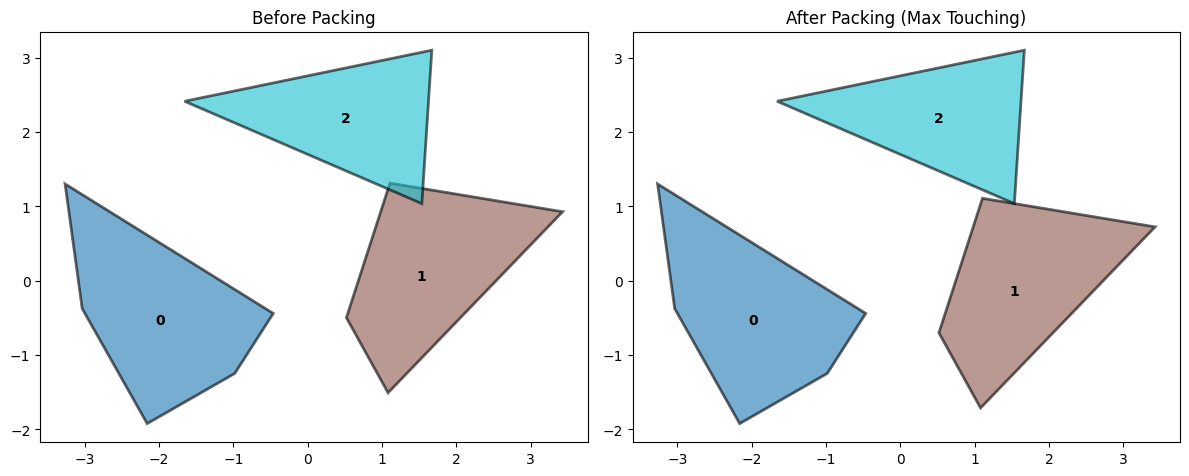

Intersecting pairs after packing: [(0, 1), (0, 2), (1, 2)]


In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))
plot_polygons(polygons, title="Before Packing", ax=ax1)
plot_polygons(packed_polygons, title="After Packing (Max Touching)", ax=ax2)
plt.tight_layout()
plt.show()

# Verify no intersections remain
new_pairs = find_intersecting_pairs_shamos(packed_polygons)
print("Intersecting pairs after packing:", new_pairs)

## 8. Alternative: Force All Pairs to Touch (If Possible)

If you want to enforce that **every** pair of polygons touches (a highly constrained packing problem), you can add:

```python
for var in touch_vars.values():
    prob += var == 1
```

This will likely make the problem infeasible unless the polygons are arranged appropriately.